<a href="https://colab.research.google.com/github/deepto123/Neural-Networks-and-LLMs/blob/main/Understanding_Wavenet_and_CNNs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Wavenet

Even if we feed all embeddings all at once to the next layer it will be crushed and information is not propagated prperly even with mutiple layers.

In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

g = torch.Generator().manual_seed(2147483647)

In [ ]:
# download the names.txt file from github
!wget https://raw.githubusercontent.com/karpathy/makemore/master/names.txt

# read in all the words
names = open('names.txt', 'r').read().splitlines()
print(len(names))
print(max(len(w) for w in names))
print(names[:8])

--2026-06-18 14:27:04--  https://raw.githubusercontent.com/karpathy/makemore/master/names.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 228145 (223K) [text/plain]
Saving to: ‘names.txt’

names.txt           100%[===================>] 222.80K  --.-KB/s    in 0.004s  

2026-06-18 14:27:04 (61.5 MB/s) - ‘names.txt’ saved [228145/228145]

32033
15
['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']


In [ ]:
chars = sorted(list(set(''.join(names))))
stoi = {ch:i+1 for i, ch in enumerate(chars)}
stoi['.'] = 0
print(stoi)

itos = {i:s for s,i in stoi.items()}
print(itos)

{'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26, '.': 0}
{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [ ]:
context_window = 8

def build_dataset(words):

  xs = []
  ys = []
  for name in words:
    string = ['.'] *context_window + list(name) + ['.']
    for i in range(len(string) - context_window):
      context = [stoi[ch] for ch in string[i:i+context_window]]
      output = stoi[string[i+context_window]]

      xs.append(context)
      ys.append(output)

  xs = torch.tensor(xs)
  ys = torch.tensor(ys)
  return xs, ys

import random
random.seed(42)
random.shuffle(names)

n1 = int(0.8 * len(names))
n2 = int(0.9 * len(names))

print(n1)
print(n2)
x_train, y_train = build_dataset(names[:n1])
x_val, y_val = build_dataset(names[n1:n2])
x_test, y_test = build_dataset(names[n2:])

25626
28829


In [ ]:
class Linear:
  def __init__(self, fan_in, fan_out, bias = True):
    self.weight = torch.randn((fan_in, fan_out), generator=g) / fan_in**0.5
    self.bias = torch.randn(fan_out, generator=g) if bias else None

  def __call__(self, input):
    self.out = input @ self.weight
    if self.bias is not None:
      self.out += self.bias
    return self.out

  def parameters(self):
    return [self.weight] + ([] if self.bias is None else [self.bias])



In [ ]:
class Tanh:
  def __call__(self, input):
    self.out = torch.tanh(input)
    return self.out

  def parameters(self):
    return []


In [ ]:
class BatchNorm1d:
  def __init__(self,num_features, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True):
    self.eps = eps
    self.momentum = momentum
    self.training = track_running_stats

    #  parameters(trained with backprop)
    self.gamma = torch.ones(num_features) # equivalent to batch norm gain
    self.beta = torch.zeros(num_features) # equivalent to batch norm bias

    # buffers (trained with a )
    self.running_mean = torch.zeros(num_features)
    self.running_var = torch.ones(num_features)

  def __call__(self, input):

    if self.training:
      if input.ndim == 2:
        dim =0
      elif input.ndim == 3:
        dim = (0,1)
      current_mean = input.mean(dim, keepdim = True)
      current_var = input.var(dim, keepdim = True)
    else:
      current_mean = self.running_mean
      current_var = self.running_var

    # Step 1:- substract from mean and divide by stnd deviation
    input_hat = (input - current_mean)/ torch.sqrt(current_var + self.eps)

    # Step 2:scale and shift
    self.out = self.gamma * input_hat + self.beta

    # recalculate the running mean
    if self.training:
      with torch.no_grad():
        self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * current_mean
        self.running_var = (1 - self.momentum) * self.running_var + self.momentum * current_var

    return self.out

  def parameters(self):
    return [self.gamma, self.beta]



In [ ]:
class Embedding:
  def __init__(self, context_window, n_embeddings):
    self.weight = torch.randn((vocab_size, n_embedding), generator=g)

  def __call__(self, input):
    self.out = self.weight[input]
    return self.out

  def parameters(self):
    return [self.weight]


In [ ]:
class FlattenConsecutive:
  def __init__(self, n):
    # n is the number of consecutive inputs we want. For ex [4, 80] we want to cast to [4,4,20] so basically 2 charcater *10 embeddings so n =2
    self.n = n

  def __call__(self, input):
    B, T, C = input.shape
    input = input.view(B, T//self.n, C*self.n)
    if input.shape[1] == 1:
      # input = input.squeeze(1)
      input = input.view(B, C*self.n)
    self.out = input
    return self.out

  def parameters(self):
    return []


In [ ]:
class Sequential:
  def __init__(self, layers):
    self.layers = layers

  def __call__(self, input):
    for layer in self.layers:
      out = layer(input)
      input = out
    self.out = out
    return self.out

  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]


In [ ]:
n_embedding = 24
n_hidden = 128
vocab_size = 27
batch_size = 32
max_steps = 200000

model = Sequential([
    Embedding(context_window, n_embedding),
    FlattenConsecutive(2), Linear(n_embedding * 2, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size)# its perfecty fine to plave it after the last layer
])

# We should never track grad during normalisation, tell the model forget the scaling and accept the new baseline truth
with torch.no_grad():
  # make the last layer less confident so that initial loss is less and we dont get a hockey stick
  model.layers[-1].weight *=.1

parameters = model.parameters()

# Print the shape of each tensor in the parameters list
for i, p in enumerate(parameters):
    print(f"Tensor {i}: {p.shape}")

print(sum(p.nelement() for p in parameters)) ## number of params in total
for p in parameters:
  p.requires_grad = True


Tensor 0: torch.Size([27, 24])
Tensor 1: torch.Size([48, 128])
Tensor 2: torch.Size([128])
Tensor 3: torch.Size([128])
Tensor 4: torch.Size([128])
Tensor 5: torch.Size([256, 128])
Tensor 6: torch.Size([128])
Tensor 7: torch.Size([128])
Tensor 8: torch.Size([128])
Tensor 9: torch.Size([256, 128])
Tensor 10: torch.Size([128])
Tensor 11: torch.Size([128])
Tensor 12: torch.Size([128])
Tensor 13: torch.Size([128, 27])
Tensor 14: torch.Size([27])
76963


In [ ]:
ix = torch.randint(0, x_train.shape[0], (4,)) # return 32 random numbers between 0 and given number
x_batch = x_train[ix]
y_batch = y_train[ix]

logits = model(x_batch)
print(x_batch.shape)
x_batch

torch.Size([4, 8])


tensor([[ 0,  0, 23,  1, 12, 20, 15, 14],
        [ 0,  0,  0, 19,  8,  1, 14, 14],
        [ 0,  0,  0,  0,  0, 13,  1, 18],
        [ 0,  0,  0,  0,  0,  0,  0,  0]])

In [ ]:
for layer in model.layers:
  print(layer.__class__.__name__, ':', tuple(layer.out.shape))

Embedding : (4, 8, 24)
FlattenConsecutive : (4, 4, 48)
Linear : (4, 4, 128)
BatchNorm1d : (4, 4, 128)
Tanh : (4, 4, 128)
FlattenConsecutive : (4, 2, 256)
Linear : (4, 2, 128)
BatchNorm1d : (4, 2, 128)
Tanh : (4, 2, 128)
FlattenConsecutive : (4, 256)
Linear : (4, 128)
BatchNorm1d : (4, 128)
Tanh : (4, 128)
Linear : (4, 27)


In [ ]:
(torch.randn(4, 5, 80) @ torch.randn(80, 100) + torch.randn(100)).shape

torch.Size([4, 5, 100])

In [ ]:
# (1 2) (3 4) (5 6) (7 8)
# instead of 8 characters i.e.e 80 embeddings we want only 2 characters i.e. 20 embeddings to pass at a time in groups of 4
(torch.randn(4, 4, 20) @ torch.randn(20, 100) + torch.randn(100)).shape

torch.Size([4, 4, 100])

In [ ]:
e = torch.randn(4, 8, 10)
e.view(4, -1, 20).shape


torch.Size([4, 4, 20])

In [ ]:
losses = []
update_to_data_ratio = []

for i in range(max_steps):

  # minibatch construct
  ix = torch.randint(0, x_train.shape[0], (batch_size,)) # return 32 random numbers between 0 and given number
  x_batch = x_train[ix]
  y_batch = y_train[ix]

  # forward pass
  logits = model(x_batch)
  loss = F.cross_entropy(logits, y_batch) # softmax activation and loss caculation

  # backward pass
  # for layer in layers:
  #   layer.out.retain_grad()   # ask pytorvh to retain gards for hidden layers
  for p in parameters:
    p.grad =None
  loss.backward()

  # update the weights
  lr = 0.05 if i < 100000 else 0.01
  for p in parameters:
    p.data -= lr * p.grad

  # track metrics
  if i% 10000 == 0: #print every once in a while
    print(f'step:{i}, loss: {loss.item():.4f}')
  losses.append(loss.log10().item())  # this is done to faltten the loss in the graph

step:0, loss: 3.3663
step:10000, loss: 2.1784
step:20000, loss: 1.9243
step:30000, loss: 1.9175
step:40000, loss: 1.9856
step:50000, loss: 1.7423
step:60000, loss: 2.0660
step:70000, loss: 1.6953
step:80000, loss: 2.1272
step:90000, loss: 2.0570
step:100000, loss: 1.6669
step:110000, loss: 1.4040
step:120000, loss: 1.9151
step:130000, loss: 2.2514
step:140000, loss: 2.1039
step:150000, loss: 1.6937
step:160000, loss: 1.7002
step:170000, loss: 2.1788
step:180000, loss: 2.3142
step:190000, loss: 1.6662


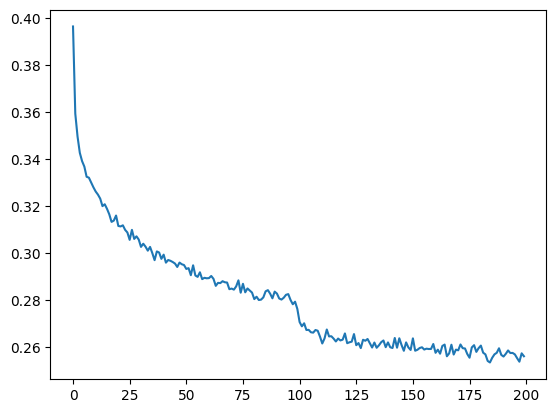

In [ ]:
losses = torch.tensor(losses)
losses_batch = losses.view(-1, 1000).mean(dim = 1, keepdim = True)

plt.plot(losses_batch)

In [ ]:
# before calculating the training and val losses set the training to false
for layer in model.layers:
  layer.training = False

In [ ]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x, y = {
      'train': {x_train, y_train},
      'val': {x_val, y_val},
      'test': {x_test, y_test}
  }[split]

  logits = model(x)
  loss = F.cross_entropy(logits, y) # softmax activation and loss caculation
  print(split, loss.item())

split_loss('train')
split_loss('val')


train 1.7889717817306519
val 1.9983978271484375


In [ ]:
for _ in range(20):

    result = []
    context = [0] * context_window # initialize with all ...
    while True:
      # forward pass the neural net
      logits = model(torch.tensor([context]))
      probs = F.softmax(logits, dim=1)
      # sample from the distribution
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      # shift the context window and track the samples
      context = context[1:] + [ix]
      result.append(ix)
      # if we sample the special '.' token, break
      if ix == 0:
        break

    print(''.join(itos[i] for i in result)) # decode and print the generated word

nevaeh.
favontay.
angelia.
aarisma.
hallen.
clautone.
jaxion.
kimberlie.
cathoni.
janely.
esada.
pabili.
beneket.
brick.
ellisa.
nellyana.
kahlia.
laiken.
mostyn.
late.


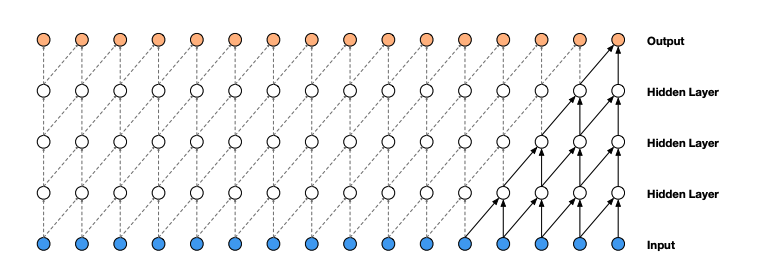

In [ ]:
# n_embedding = 10
# n_hidden = 100
# vocab_size = 27
# batch_size = 32
# max_steps = 200000
# context_window = 3
# model = Sequential([
#     Embedding(context_window, n_embedding),
#     Flatten(),
#     Linear(context_window * n_embedding, n_hidden), BatchNorm1d(n_hidden), Tanh(),
#     Linear(n_hidden, vocab_size)# its perfecty fine to plave it after the last layer
# ])
# train 2.119051694869995
# val 2.144991636276245

# context_window = 3
# train 2.0133650302886963
# val 2.0765762329101562

# with wavenet
# train 1.889196753501892
# val 2.0122036933898926


1. Types of gradient descent
2. Types of normalisation

In [ ]:
e = torch.randn(32, 4, 128)
print(e.shape)
emean = e.mean(0, keepdim = True) # 1,4,68
print(emean.shape)
# evar = e.var(0, keepdim=True)

torch.Size([32, 4, 128])
torch.Size([1, 4, 128])


In [ ]:
model.layers[3].running_mean.shape

# The 4 is teated as a separate dimenion while calculating the mean. So we get a total of 4 means instead of a single running mean for our samples
# However we want to treat the 4 as a batch dimension.

# So we want to average over 32 *4 for eahc of the 128 neurons or samples.

torch.Size([1, 4, 128])

In [ ]:
e = torch.randn(32, 4, 128)
print(e.shape)
emean = e.mean((0,1), keepdim = True) # 1,4,68
print(emean.shape)
# evar = e.var(0, keepdim=True)

torch.Size([32, 4, 128])
torch.Size([1, 1, 128])
